In [1]:
import os
import wandb
import torch
import random
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from torch.utils.data import Dataset

from modules.dna_tokenizer import DNATokenizer
from modules.bert_config import BertConfig
from modules.custom_bert import DNABertForMaskedLM

from transformers import DataCollatorForLanguageModeling
from transformers import Trainer, TrainingArguments

In [2]:
# Global configuration wandb
os.environ["WANDB_PROJECT"] = "dna-indel-prediction"  # project name
os.environ["WANDB_LOG_MODEL"] = "false"
# os.environ["WANDB_API_KEY"] = api key should be set in terminal

# Initialer Login (falls noch nicht geschehen)
wandb.login()

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print("Using device: ", device)

wandb: Currently logged in as: selin-t (selin-t-technical-university-of-munich) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Using device:  mps


In [3]:
# Create tokenizer
tokenizer = DNATokenizer()

# Test
seq = "ATC---GATCG"
tokens = tokenizer(seq, return_tensors="pt")
print(tokens)

{'input_ids': tensor([[7, 0, 1, 2, 4, 4, 4, 3, 0, 1, 2, 3, 8, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         5, 5,

In [4]:
with open("../config.json", "r") as f:
    config_dict = json.load(f)

config = BertConfig(**config_dict)

model = DNABertForMaskedLM(config)


In [5]:
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.15  # fraction of nucleotides to mask
)

In [6]:
class DNADataset(Dataset):
    def __init__(self, sequences, tokenizer, max_length=512):
        self.sequences = sequences
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        item = self.tokenizer(
                    self.sequences[idx],
                    padding="max_length",
                    #truncation=True,
                    max_length=self.max_length,
                    #return_special_tokens_mask=True,
                )
        return {k: v.squeeze(0) for k, v in item.items()}


train_df = pd.read_parquet("../data/simulated/train.parquet")
val_df   = pd.read_parquet("../data/simulated/val.parquet")

train_sequences = train_df["sequences"].tolist()
val_sequences   = val_df["sequences"].tolist()

train_dataset = DNADataset(sequences=train_sequences, tokenizer=tokenizer)
eval_dataset  = DNADataset(sequences=val_sequences, tokenizer=tokenizer)

print(f"Loaded {len(train_dataset)} training samples and {len(eval_dataset)} validation samples.")

Loaded 30000 training samples and 10000 validation samples.


In [7]:
sample = train_dataset[0]
print(sample["input_ids"].shape)

torch.Size([512])


In [ ]:
# Custom DataCollator that extends transformers' DataCollatorForLanguageModeling
class CustomDataCollatorForMLM(DataCollatorForLanguageModeling):
    def torch_mask_tokens(self, inputs, special_tokens_mask=None, **kwargs):
        """
        Override the masking method to use our custom mask_sequence logic.
        """
        labels = inputs.clone()
        # We sample a few tokens in each sequence for MLM training 
        probability_matrix = torch.full(labels.shape, self.mlm_probability)
        
        if special_tokens_mask is None:
            special_tokens_mask = [
                self.tokenizer.get_special_tokens_mask(val, already_has_special_tokens=True) 
                for val in labels.tolist()
            ]
            special_tokens_mask = torch.tensor(special_tokens_mask, dtype=torch.bool)
        else:
            special_tokens_mask = special_tokens_mask.bool()

        probability_matrix.masked_fill_(special_tokens_mask, value=0.0)
        masked_indices = torch.bernoulli(probability_matrix).bool()
        labels[~masked_indices] = -100  # We only compute loss on masked tokens

        # Apply our custom masking logic (80/10/10 rule)
        for i in range(inputs.shape[0]):  # For each sequence in batch
            for j in range(inputs.shape[1]):  # For each token in sequence
                if masked_indices[i, j]:
                    prob = random.random()
                    if prob < 0.8:  # 80% of time: replace with [MASK]
                        inputs[i, j] = self.tokenizer.mask_token_id
                    elif prob < 0.9:  # 10% of time: replace with random DNA token
                        # Random DNA token (A, T, C, G are tokens 0, 1, 2, 3)
                        inputs[i, j] = random.choice([0, 1, 2, 3])
                    # 10% of time: keep original (no change needed)

        return inputs, labels

# Create the custom data collator
custom_data_collator = CustomDataCollatorForMLM(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.15
)

# Training with validation every epoch
training_args = TrainingArguments(
    output_dir="../checkpoints",
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_steps=5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    learning_rate=1e-4,
    report_to="wandb",
    run_name="simulated_data_run_v1"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=custom_data_collator
)

trainer.train()

wandb.finish()

/Users/selin/PycharmProjects/InsDelGLM/.venv/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch,Training Loss,Validation Loss


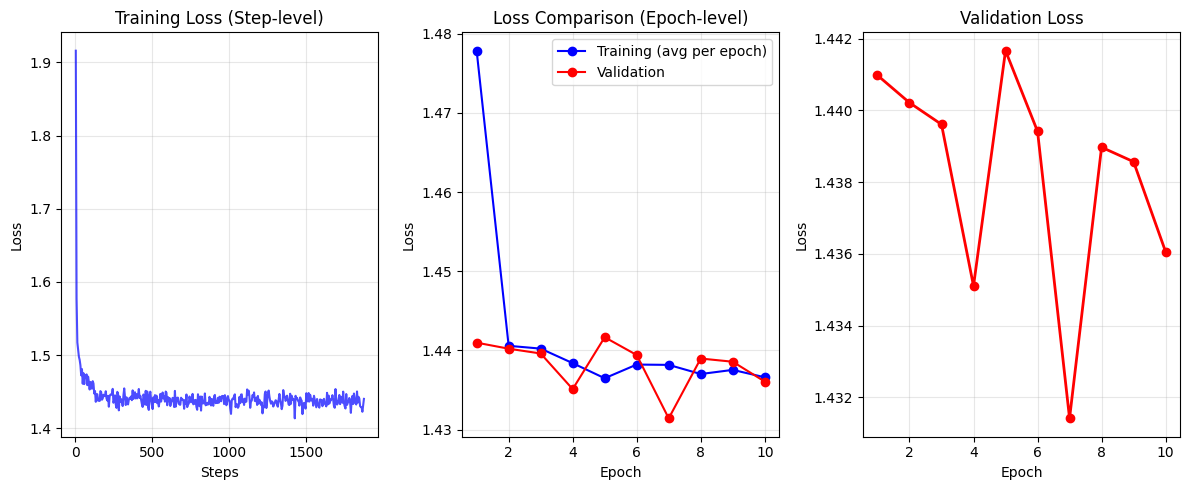

In [33]:
# Plot loss curves
logs = trainer.state.log_history
train_logs = [x for x in logs if 'loss' in x and 'eval_loss' not in x]
eval_logs = [x for x in logs if 'eval_loss' in x]

# Get step-level training loss
train_steps = [x['step'] for x in train_logs]
train_losses = [x['loss'] for x in train_logs]

# Get epoch-level validation loss
eval_epochs = [x['epoch'] for x in eval_logs]
eval_losses = [x['eval_loss'] for x in eval_logs]

# Calculate epoch-averaged training loss
epochs = list(range(1, int(max(eval_epochs)) + 1))
train_loss_per_epoch = []

for epoch in epochs:
    # Find training losses for this epoch
    epoch_start = (epoch - 1) * (len(train_dataset) // 16)  # steps per epoch
    epoch_end = epoch * (len(train_dataset) // 16)

    epoch_losses = [loss for step, loss in zip(train_steps, train_losses)
                   if epoch_start < step <= epoch_end]

    if epoch_losses:
        train_loss_per_epoch.append(np.mean(epoch_losses))
    else:
        train_loss_per_epoch.append(None)

plt.figure(figsize=(12, 5))

# Plot 1: Step-level training loss
plt.subplot(1, 3, 1)
plt.plot(train_steps, train_losses, 'b-', alpha=0.7)
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training Loss (Step-level)')
plt.grid(True, alpha=0.3)

# Plot 2: Epoch-level comparison
plt.subplot(1, 3, 2)
plt.plot(epochs, train_loss_per_epoch, 'bo-', label='Training (avg per epoch)')
plt.plot(eval_epochs, eval_losses, 'ro-', label='Validation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Comparison (Epoch-level)')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Validation loss only
plt.subplot(1, 3, 3)
plt.plot(eval_epochs, eval_losses, 'ro-', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
project_root = Path.cwd().parent
save_directory = project_root / "model" / "test"

trainer.save_model(str(save_directory))